### Import Library and data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
import os

# Set global visual style for professional portfolio presentation
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.size"] = 10
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.titleweight"] = "bold"

os.makedirs("../outputs/figures", exist_ok=True)
os.makedirs("../outputs/tables", exist_ok=True)

df = pd.read_csv(
    "../data/processed/tourism_arrivals_clean.csv"
)

yearly = (
    df.groupby("Year")["Tourist_Arrivals"]
    .sum()
    .reset_index()
)

yearly

,Year,Tourist_Arrivals
0,2018,2333796.0
1,2019,1913702.0
2,2020,507702.0
3,2021,194494.0
4,2022,719978.0
5,2023,1487303.0
6,2024,2053465.0
7,2025,2362521.0


### Line chart

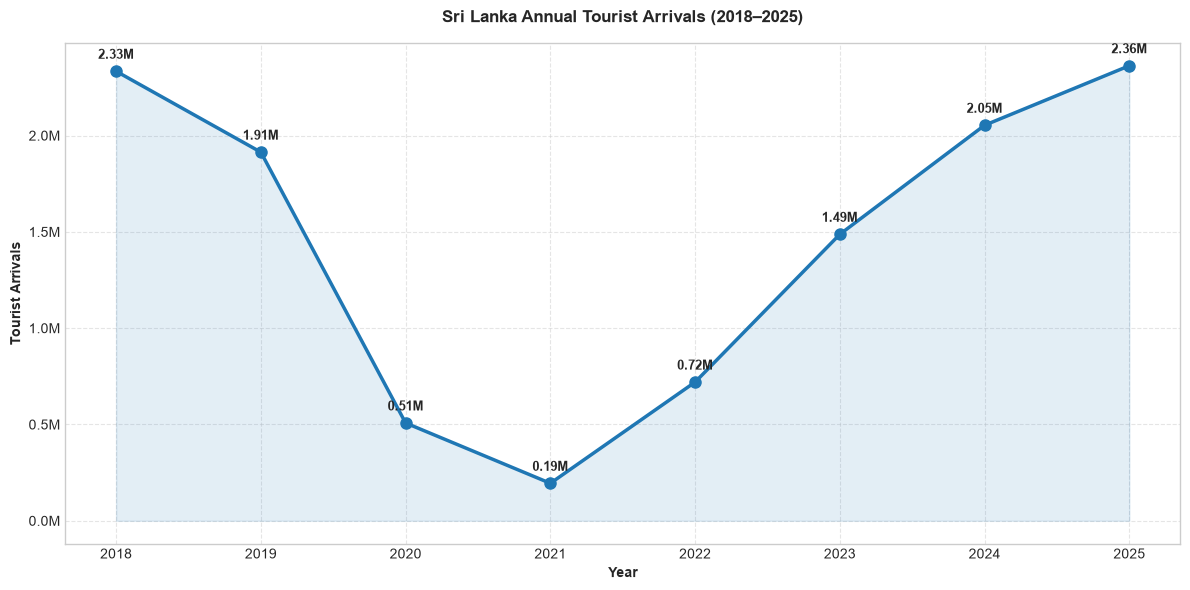

In [2]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    yearly["Year"],
    yearly["Tourist_Arrivals"],
    marker="o",
    color="#1f77b4",
    linewidth=2.5,
    markersize=8,
    label="Annual Arrivals"
)

ax.fill_between(
    yearly["Year"],
    yearly["Tourist_Arrivals"],
    color="#1f77b4",
    alpha=0.12
)

# Format y-axis in Millions
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{x*1e-6:.1f}M"))

# Direct value annotations
for _, row in yearly.iterrows():
    ax.annotate(
        f"{row['Tourist_Arrivals']*1e-6:.2f}M",
        (row["Year"], row["Tourist_Arrivals"]),
        textcoords="offset points",
        xytext=(0, 9),
        ha="center",
        fontsize=9.5,
        fontweight="bold"
    )

ax.set_title("Sri Lanka Annual Tourist Arrivals (2018–2025)", pad=15)
ax.set_xlabel("Year", fontweight="bold")
ax.set_ylabel("Tourist Arrivals", fontweight="bold")
ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("../outputs/figures/yearly_tourism_performance.png", dpi=300)
plt.show()

### Year over Year Growth Analysis

In [3]:
yearly = (
    df.groupby("Year")["Tourist_Arrivals"]
    .sum()
    .reset_index()
)

yearly["YoY_Growth_%"] = (
    yearly["Tourist_Arrivals"]
    .pct_change()
    * 100
)

yearly

,Year,Tourist_Arrivals,YoY_Growth_%
0,2018,2333796.0,NaN
1,2019,1913702.0,-18.000459
2,2020,507702.0,-73.470164
3,2021,194494.0,-61.691307
4,2022,719978.0,270.180057
5,2023,1487303.0,106.576173
6,2024,2053465.0,38.066352
7,2025,2362521.0,15.050463


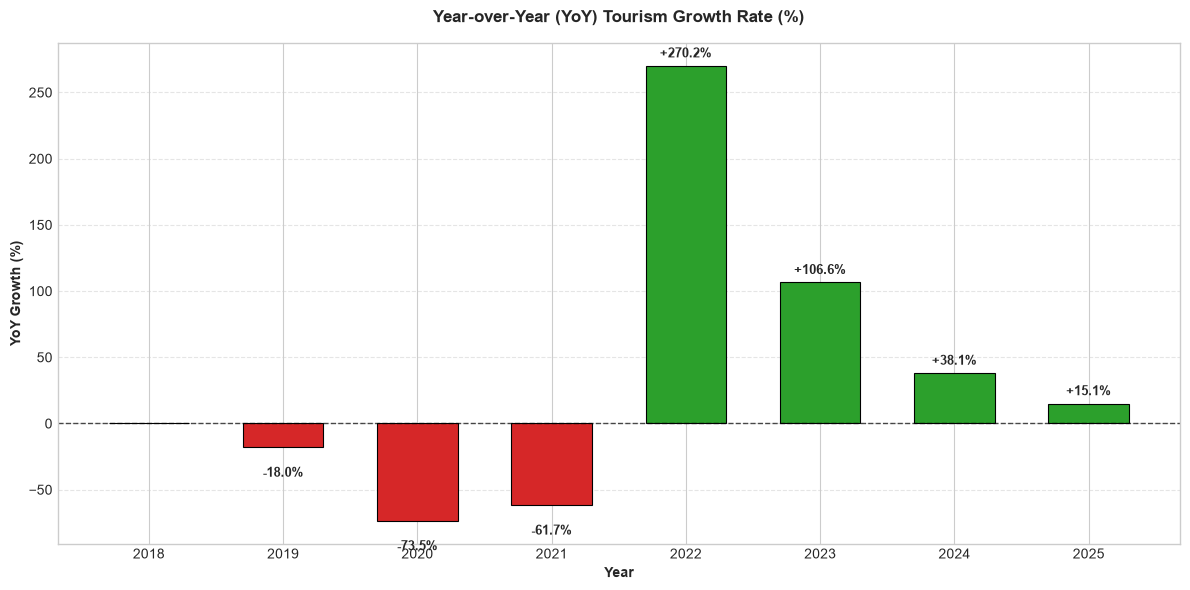

In [4]:
fig, ax = plt.subplots(figsize=(12, 6))

colors = ["#2ca02c" if val >= 0 else "#d62728" for val in yearly["YoY_Growth_%"].fillna(0)]

bars = ax.bar(
    yearly["Year"].astype(str),
    yearly["YoY_Growth_%"].fillna(0),
    color=colors,
    width=0.6,
    edgecolor="black",
    linewidth=0.8
)

ax.axhline(0, color="black", linestyle="--", linewidth=1, alpha=0.7)

# Data labels on bars
for bar in bars:
    height = bar.get_height()
    va = "bottom" if height >= 0 else "top"
    offset = 4 if height >= 0 else -14
    if not np.isnan(height) and height != 0:
        ax.annotate(
            f"{height:+.1f}%",
            (bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, offset),
            textcoords="offset points",
            ha="center",
            va=va,
            fontsize=9.5,
            fontweight="bold"
        )

ax.set_title("Year-over-Year (YoY) Tourism Growth Rate (%)", pad=15)
ax.set_xlabel("Year", fontweight="bold")
ax.set_ylabel("YoY Growth (%)", fontweight="bold")
ax.grid(True, linestyle="--", alpha=0.5, axis="y")

plt.tight_layout()
plt.show()

### Monthly and Seasonality Analysis

In [5]:
monthly = (
    df.groupby(
        ["Month_Number", "Month"]
    )["Tourist_Arrivals"]
    .sum()
    .reset_index()
    .sort_values("Month_Number")
)

monthly

,Month_Number,Month,Tourist_Arrivals
0,1,January,1359165.0
1,2,February,1361237.0
2,3,March,1224133.0
3,4,April,843525.0
4,5,May,527328.0
5,6,June,596469.0
6,7,July,914345.0
7,8,August,885995.0
8,9,September,694060.0
9,10,October,746961.0


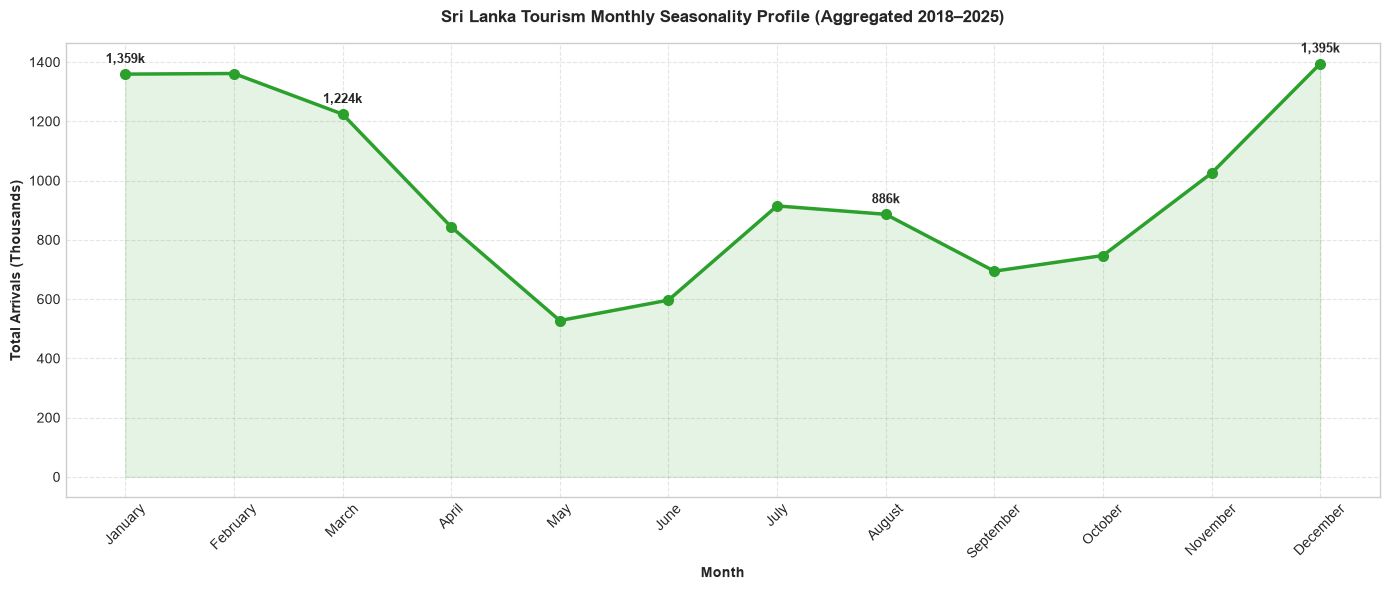

In [6]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    monthly["Month"],
    monthly["Tourist_Arrivals"] / 1e3,
    marker="o",
    color="#2ca02c",
    linewidth=2.5,
    markersize=7
)

ax.fill_between(
    monthly["Month"],
    monthly["Tourist_Arrivals"] / 1e3,
    color="#2ca02c",
    alpha=0.12
)

# Highlight peak months (December & January)
for _, row in monthly.iterrows():
    if row["Month"] in ["December", "January", "March", "August"]:
        ax.annotate(
            f"{row['Tourist_Arrivals']/1e3:,.0f}k",
            (row["Month"], row["Tourist_Arrivals"] / 1e3),
            textcoords="offset points",
            xytext=(0, 8),
            ha="center",
            fontsize=9,
            fontweight="bold"
        )

ax.set_title("Sri Lanka Tourism Monthly Seasonality Profile (Aggregated 2018–2025)", pad=15)
ax.set_xlabel("Month", fontweight="bold")
ax.set_ylabel("Total Arrivals (Thousands)", fontweight="bold")
ax.tick_params(axis="x", rotation=45)
ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

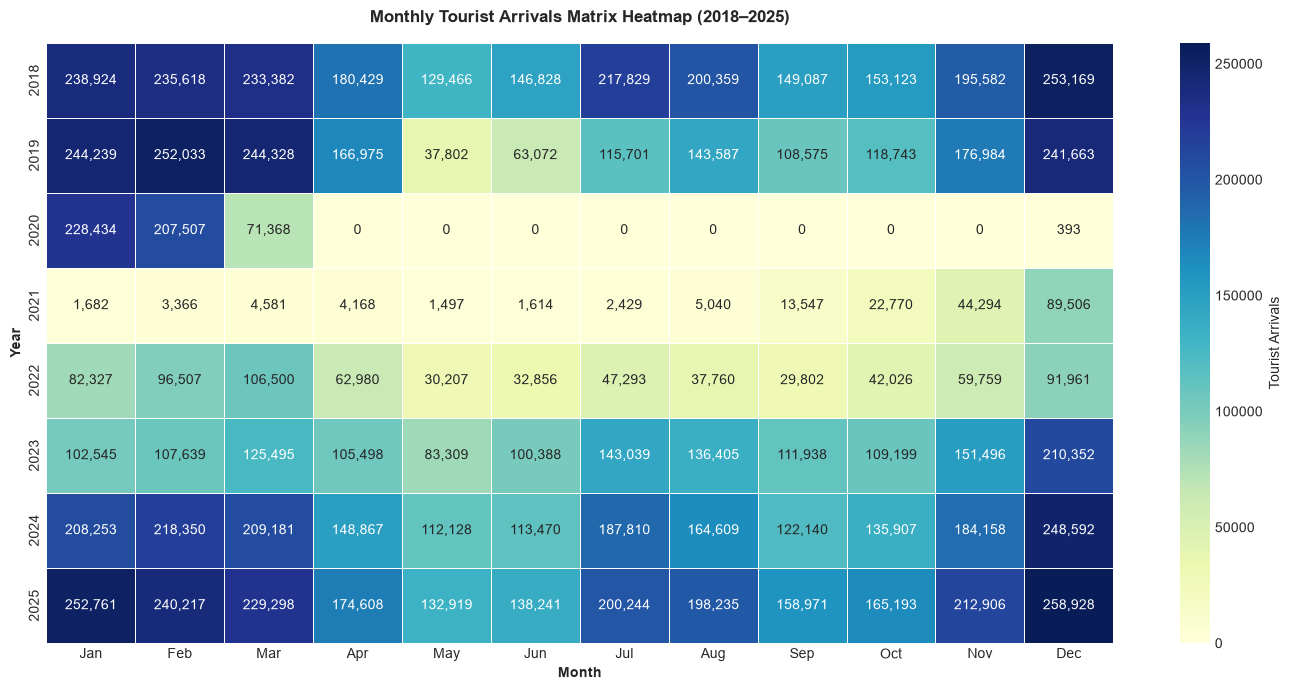

In [7]:
heatmap_data = df.pivot_table(
    index="Year",
    columns="Month_Number",
    values="Tourist_Arrivals",
    aggfunc="sum"
)

month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

plt.figure(figsize=(14, 7))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=",.0f",
    cmap="YlGnBu",
    cbar_kws={"label": "Tourist Arrivals"},
    xticklabels=month_labels,
    linewidths=0.5
)

plt.title("Monthly Tourist Arrivals Matrix Heatmap (2018–2025)", pad=15)
plt.xlabel("Month", fontweight="bold")
plt.ylabel("Year", fontweight="bold")

plt.tight_layout()
plt.show()

### Country_Market_Analysis

In [8]:
country = (
    df.groupby("Country")["Tourist_Arrivals"]
    .sum()
    .reset_index()
    .sort_values(
        "Tourist_Arrivals",
        ascending=False
    )
)

country.head(20)

,Country,Tourist_Arrivals
80,India,2299847.0
192,United Kingdom,1130944.0
149,Russia,894607.0
37,China,799612.0
66,Germany,780867.0
10,Australia,525726.0
62,France,515008.0
193,United States,361185.0
109,Maldives,292660.0
33,Canada,278059.0


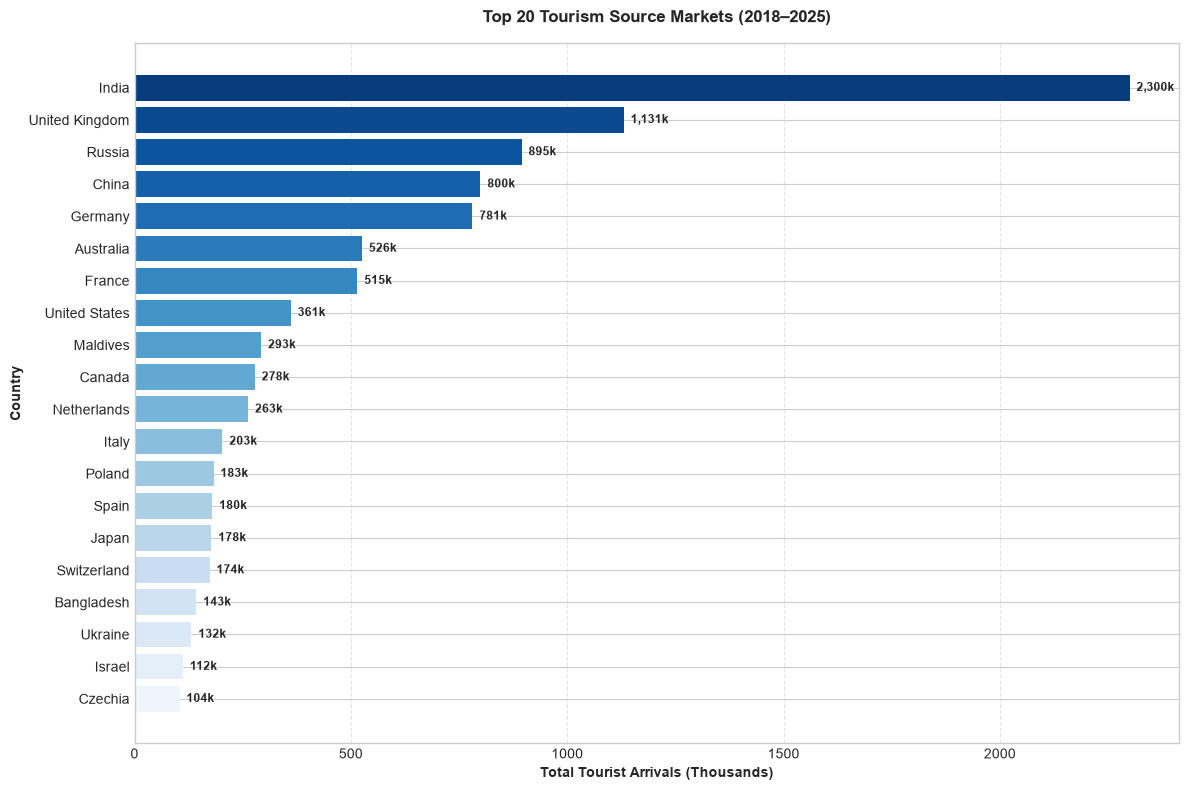

In [9]:
top20 = country.head(20).copy()

plt.figure(figsize=(12, 8))

colors = sns.color_palette("Blues_r", len(top20))
bars = plt.barh(
    top20["Country"][::-1],
    top20["Tourist_Arrivals"][::-1] / 1e3,
    color=colors[::-1],
    edgecolor="none"
)

for bar in bars:
    w = bar.get_width()
    plt.annotate(
        f"{w:,.0f}k",
        (w, bar.get_y() + bar.get_height() / 2),
        xytext=(5, 0),
        textcoords="offset points",
        va="center",
        fontsize=8.5,
        fontweight="bold"
    )

plt.title("Top 20 Tourism Source Markets (2018–2025)", pad=15)
plt.xlabel("Total Tourist Arrivals (Thousands)", fontweight="bold")
plt.ylabel("Country", fontweight="bold")
plt.grid(True, linestyle="--", alpha=0.5, axis="x")

plt.tight_layout()
plt.show()

### Country_Market_Share_Analysis

In [10]:
country = (
    df.groupby("Country")["Tourist_Arrivals"]
    .sum()
    .reset_index()
)

total_arrivals = country[
    "Tourist_Arrivals"
].sum()

country["Market_Share_%"] = (
    country["Tourist_Arrivals"]
    / total_arrivals
    * 100
)

country = country.sort_values(
    "Market_Share_%",
    ascending=False
)

country.head(20)

,Country,Tourist_Arrivals,Market_Share_%
80,India,2299847.0,19.872589
192,United Kingdom,1130944.0,9.772296
149,Russia,894607.0,7.730148
37,China,799612.0,6.909312
66,Germany,780867.0,6.747340
10,Australia,525726.0,4.542710
62,France,515008.0,4.450097
193,United States,361185.0,3.120939
109,Maldives,292660.0,2.528826
33,Canada,278059.0,2.402661


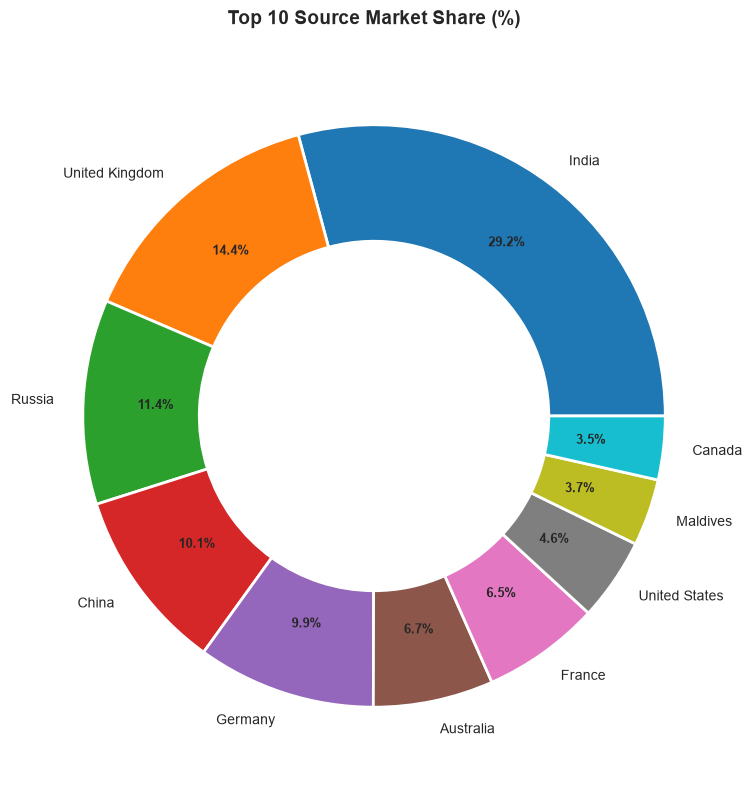

In [11]:
top10 = country.head(10).copy()

plt.figure(figsize=(9, 8))

colors = sns.color_palette("tab10", len(top10))

wedges, texts, autotexts = plt.pie(
    top10["Market_Share_%"],
    labels=top10["Country"],
    autopct="%1.1f%%",
    pctdistance=0.75,
    colors=colors,
    wedgeprops=dict(width=0.4, edgecolor="white", linewidth=2)
)

for autotext in autotexts:
    autotext.set_fontsize(9)
    autotext.set_fontweight("bold")

plt.title("Top 10 Source Market Share (%)", pad=20, fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### Country_Growth_Analysis

In [12]:
country_year = (
    df.groupby(
        ["Country", "Year"]
    )["Tourist_Arrivals"]
    .sum()
    .reset_index()
)

country_year["Growth_%"] = (
    country_year
    .groupby("Country")["Tourist_Arrivals"]
    .pct_change()
    * 100
)

country_year.head()

,Country,Year,Tourist_Arrivals,Growth_%
0,Afghanistan,2018,861.0,NaN
1,Afghanistan,2019,473.0,-45.063879
2,Afghanistan,2020,146.0,-69.133192
3,Afghanistan,2021,15.0,-89.726027
4,Afghanistan,2022,39.0,160.000000


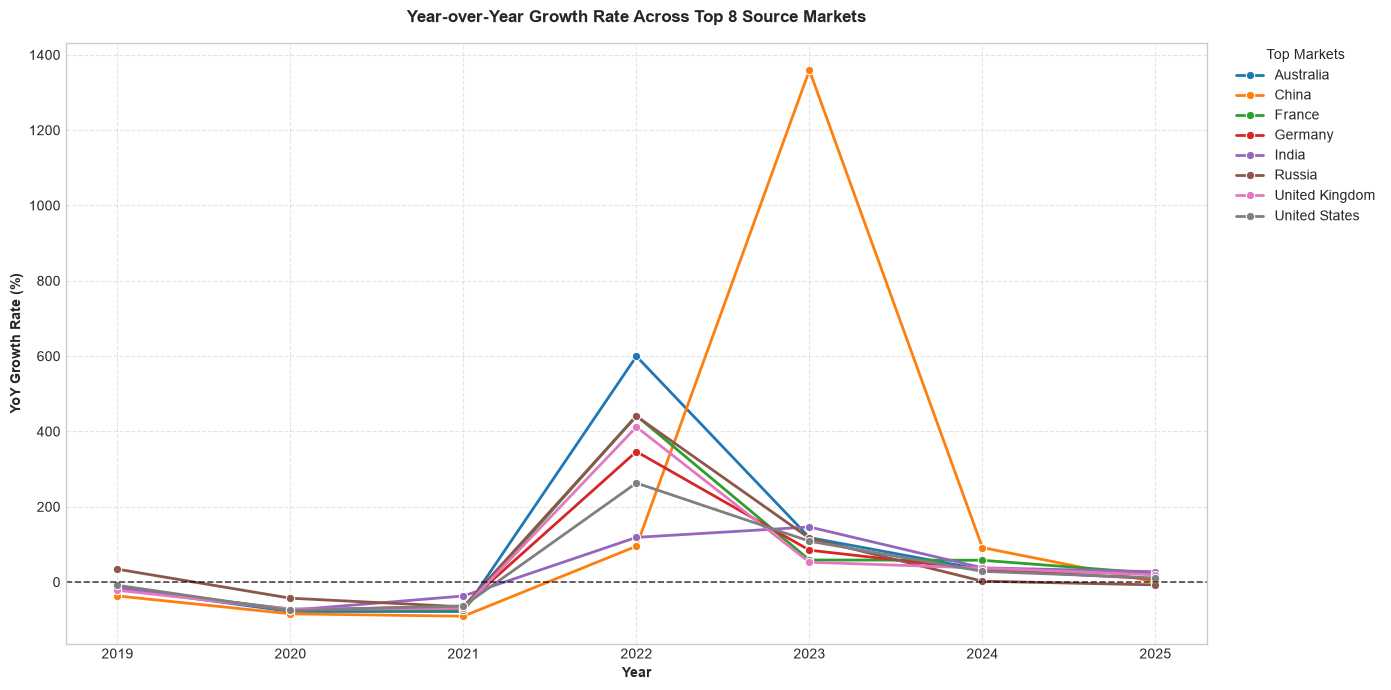

In [13]:
top_countries = (
    country_year
    .groupby("Country")["Tourist_Arrivals"]
    .sum()
    .nlargest(8)
    .index
)

growth_top = country_year[
    country_year["Country"].isin(top_countries)
]

plt.figure(figsize=(14, 7))

sns.lineplot(
    data=growth_top,
    x="Year",
    y="Growth_%",
    hue="Country",
    marker="o",
    linewidth=2,
    palette="tab10"
)

plt.axhline(0, color="black", linestyle="--", linewidth=1.2, alpha=0.7)

plt.title("Year-over-Year Growth Rate Across Top 8 Source Markets", pad=15)
plt.xlabel("Year", fontweight="bold")
plt.ylabel("YoY Growth Rate (%)", fontweight="bold")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0, title="Top Markets")
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

### Country_Ranking_Analysis

In [14]:
country_year = (
    df.groupby(
        ["Year", "Country"]
    )["Tourist_Arrivals"]
    .sum()
    .reset_index()
)

country_year["Rank"] = (
    country_year
    .groupby("Year")["Tourist_Arrivals"]
    .rank(
        method="min",
        ascending=False
    )
)

country_year["Rank"] = (
    country_year["Rank"]
    .astype(int)
)

country_year.head()

,Year,Country,Tourist_Arrivals,Rank
0,2018,Afghanistan,861.0,77
1,2018,Albania,177.0,106
2,2018,Algeria,368.0,94
3,2018,Andorra,53.0,131
4,2018,Angola,9.0,173


In [15]:
top10_each_year = country_year[
    country_year["Rank"] <= 10
].sort_values(
    ["Year", "Rank"]
)

top10_each_year

,Year,Country,Tourist_Arrivals,Rank
75,2018,India,424887.0,1
35,2018,China,265965.0,2
185,2018,United Kingdom,254176.0,3
63,2018,Germany,156888.0,4
8,2018,Australia,110928.0,5
...,...,...,...,...
1337,2025,Australia,109487.0,6
1389,2025,France,109041.0,7
1514,2025,United States,65973.0,8
1450,2025,Netherlands,64164.0,9


### Country_Month_Behavior_Analysis

In [16]:
country_month = (
    df.groupby(
        ["Country", "Month_Number", "Month"]
    )["Tourist_Arrivals"]
    .sum()
    .reset_index()
)

country_month.head()

,Country,Month_Number,Month,Tourist_Arrivals
0,Afghanistan,1,January,238.0
1,Afghanistan,2,February,301.0
2,Afghanistan,3,March,226.0
3,Afghanistan,4,April,101.0
4,Afghanistan,5,May,166.0


In [17]:
selected_country = "India"

india = country_month[
    country_month["Country"].str.upper()
    == selected_country.upper()
]

india

,Country,Month_Number,Month,Tourist_Arrivals
960,India,1,January,222734.0
961,India,2,February,192801.0
962,India,3,March,191418.0
963,India,4,April,148728.0
964,India,5,May,161191.0
965,India,6,June,148229.0
966,India,7,July,157142.0
967,India,8,August,185525.0
968,India,9,September,183882.0
969,India,10,October,201406.0


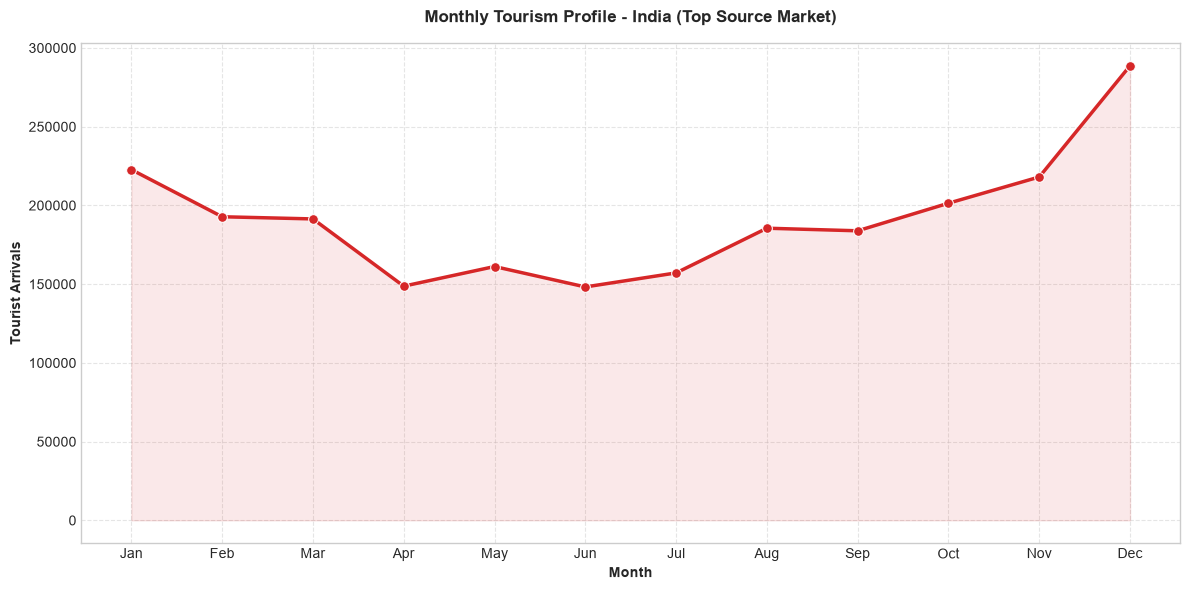

In [18]:
Month = (
    df.sort_values("Month_Number")["Month"]
    .drop_duplicates()
    .tolist()
)

month_abbr = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=india,
    x="Month_Number",
    y="Tourist_Arrivals",
    marker="o",
    color="#d62728",
    linewidth=2.5,
    markersize=7
)

plt.fill_between(
    india["Month_Number"],
    india["Tourist_Arrivals"],
    color="#d62728",
    alpha=0.1
)

plt.xticks(
    range(1, 13),
    month_abbr,
    rotation=0
)

plt.title(f"Monthly Tourism Profile - {selected_country} (Top Source Market)", pad=15)
plt.xlabel("Month", fontweight="bold")
plt.ylabel("Tourist Arrivals", fontweight="bold")
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

### Regional Market Analysis

In [19]:
import country_converter as coco

In [20]:
df["Continent"] = coco.convert(
    df["Country"],
    to="continent",
    not_found=None
)

df[
    ["Country", "Continent"]
].drop_duplicates().head(20)

Netherlands Antilles not found in regex
Netherlands Antilles not found in regex
Netherlands Antilles not found in regex
Netherlands Antilles not found in regex
Netherlands Antilles not found in regex
Netherlands Antilles not found in regex
Netherlands Antilles not found in regex
Netherlands Antilles not found in regex
Netherlands Antilles not found in regex
Netherlands Antilles not found in regex
Netherlands Antilles not found in regex
Netherlands Antilles not found in regex
Netherlands Antilles not found in regex
Netherlands Antilles not found in regex
Netherlands Antilles not found in regex
Netherlands Antilles not found in regex
Netherlands Antilles not found in regex
Netherlands Antilles not found in regex
Netherlands Antilles not found in regex
Netherlands Antilles not found in regex
Netherlands Antilles not found in regex
Netherlands Antilles not found in regex
Netherlands Antilles not found in regex
Netherlands Antilles not found in regex


,Country,Continent
0,Afghanistan,Asia
1,Albania,Europe
2,Algeria,Africa
3,Andorra,Europe
4,Angola,Africa
5,Antigua and Barbuda,America
6,Argentina,America
7,Armenia,Asia
8,Australia,Oceania
9,Austria,Europe


In [21]:
continent_summary = (
    df.groupby("Continent")["Tourist_Arrivals"]
    .sum()
    .reset_index()
    .sort_values(
        "Tourist_Arrivals",
        ascending=False
    )
)

continent_summary

,Continent,Tourist_Arrivals
4,Europe,5431841.0
3,Asia,4761506.0
1,America,683847.0
6,Oceania,592108.0
0,Africa,103655.0
5,Netherlands Antilles,3.0
2,Antarctica,1.0


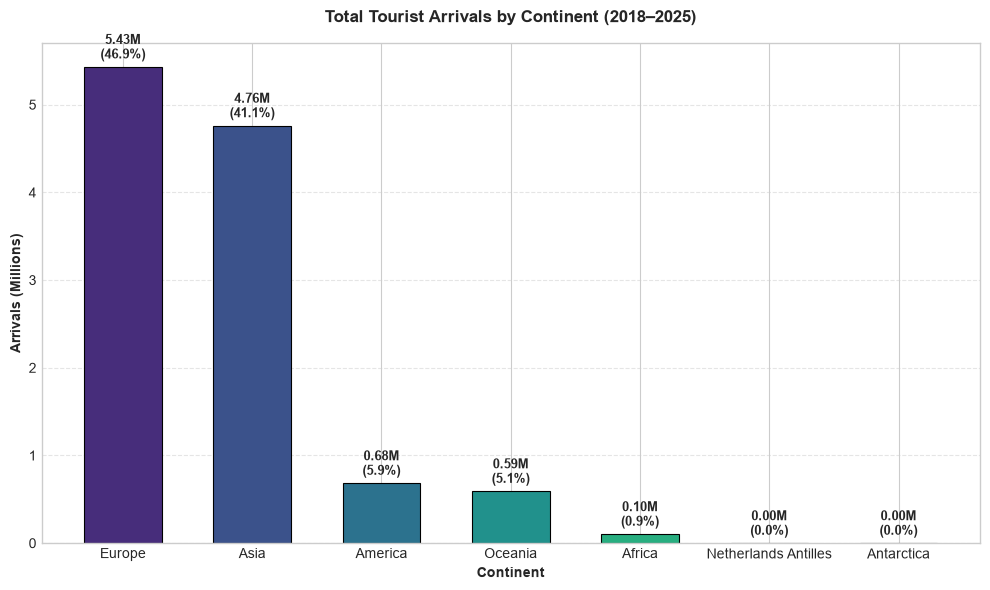

In [22]:
plt.figure(figsize=(10, 6))

colors = sns.color_palette("viridis", len(continent_summary))

bars = plt.bar(
    continent_summary["Continent"],
    continent_summary["Tourist_Arrivals"] / 1e6,
    color=colors,
    edgecolor="black",
    linewidth=0.8,
    width=0.6
)

for bar in bars:
    h = bar.get_height()
    pct = (h / (continent_summary["Tourist_Arrivals"].sum() / 1e6)) * 100
    plt.annotate(
        f"{h:.2f}M\n({pct:.1f}%)",
        (bar.get_x() + bar.get_width() / 2, h),
        xytext=(0, 6),
        textcoords="offset points",
        ha="center",
        fontsize=9,
        fontweight="bold"
    )

plt.title("Total Tourist Arrivals by Continent (2018–2025)", pad=15)
plt.xlabel("Continent", fontweight="bold")
plt.ylabel("Arrivals (Millions)", fontweight="bold")
plt.grid(True, linestyle="--", alpha=0.5, axis="y")

plt.tight_layout()
plt.show()

### Tourism_Concentration_Pareto_Analysis

In [23]:
country = (
    df.groupby("Country")["Tourist_Arrivals"]
    .sum()
    .reset_index()
    .sort_values(
        "Tourist_Arrivals",
        ascending=False
    )
)

country["Cumulative_Arrivals"] = (
    country["Tourist_Arrivals"].cumsum()
)

country["Cumulative_%"] = (
    country["Cumulative_Arrivals"]
    / country["Tourist_Arrivals"].sum()
    * 100
)

country.head(20)

,Country,Tourist_Arrivals,Cumulative_Arrivals,Cumulative_%
80,India,2299847.0,2299847.0,19.872589
192,United Kingdom,1130944.0,3430791.0,29.644885
149,Russia,894607.0,4325398.0,37.375033
37,China,799612.0,5125010.0,44.284345
66,Germany,780867.0,5905877.0,51.031685
10,Australia,525726.0,6431603.0,55.574394
62,France,515008.0,6946611.0,60.024492
193,United States,361185.0,7307796.0,63.145430
109,Maldives,292660.0,7600456.0,65.674256
33,Canada,278059.0,7878515.0,68.076917


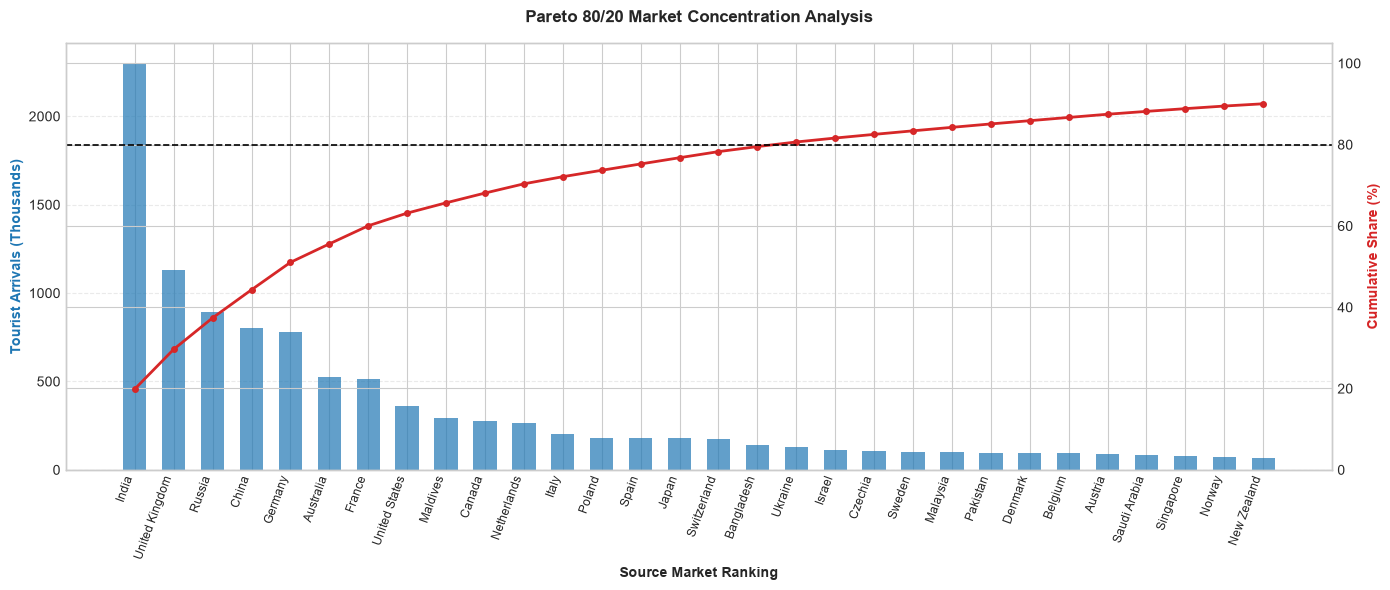

In [24]:
fig, ax1 = plt.subplots(figsize=(14, 6))

# Plot top 30 countries for clarity
country_top30 = country.head(30).reset_index(drop=True)

ax1.bar(
    range(len(country_top30)),
    country_top30["Tourist_Arrivals"] / 1e3,
    color="#1f77b4",
    alpha=0.7,
    width=0.6,
    label="Arrivals"
)
ax1.set_ylabel("Tourist Arrivals (Thousands)", fontweight="bold", color="#1f77b4")
ax1.set_xlabel("Source Market Ranking", fontweight="bold")
ax1.set_xticks(range(len(country_top30)))
ax1.set_xticklabels(country_top30["Country"], rotation=70, ha="right", fontsize=8.5)

ax2 = ax1.twinx()
ax2.plot(
    range(len(country_top30)),
    country_top30["Cumulative_%"],
    color="#d62728",
    marker="o",
    linewidth=2,
    markersize=4,
    label="Cumulative Share (%)"
)
ax2.axhline(80, color="black", linestyle="--", linewidth=1.2, label="80% Threshold")
ax2.set_ylabel("Cumulative Share (%)", fontweight="bold", color="#d62728")
ax2.set_ylim(0, 105)

plt.title("Pareto 80/20 Market Concentration Analysis", pad=15)
ax1.grid(True, linestyle="--", alpha=0.4, axis="y")

plt.tight_layout()
plt.show()

### Tourism Distribution and Outlier Analysis

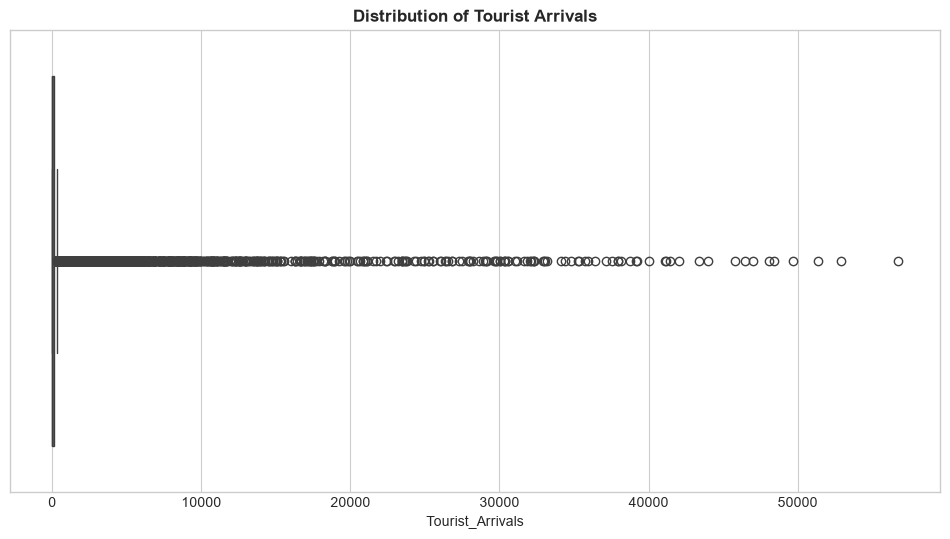

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

sns.boxplot(
    x=df["Tourist_Arrivals"]
)

plt.title(
    "Distribution of Tourist Arrivals"
)

plt.show()

In [26]:
Q1 = df["Tourist_Arrivals"].quantile(0.25)
Q3 = df["Tourist_Arrivals"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df["Tourist_Arrivals"] < lower)
    |
    (df["Tourist_Arrivals"] > upper)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Outliers:", len(outliers))

Q1: 0.0
Q3: 126.0
IQR: 126.0
Outliers: 3272


### Pre Crisis vs Post Crisis Analysis

In [27]:
df["Period"] = np.select(
    [
        df["Year"] <= 2019,
        df["Year"].isin([2020, 2021]),
        df["Year"] >= 2022
    ],
    [
        "Pre-Crisis",
        "Crisis",
        "Post-Crisis"
    ],
    default="Other"
)

period_summary = (
    df.groupby("Period")["Tourist_Arrivals"]
    .sum()
    .reset_index()
)

period_summary

,Period,Tourist_Arrivals
0,Crisis,702196.0
1,Post-Crisis,6623267.0
2,Pre-Crisis,4247498.0


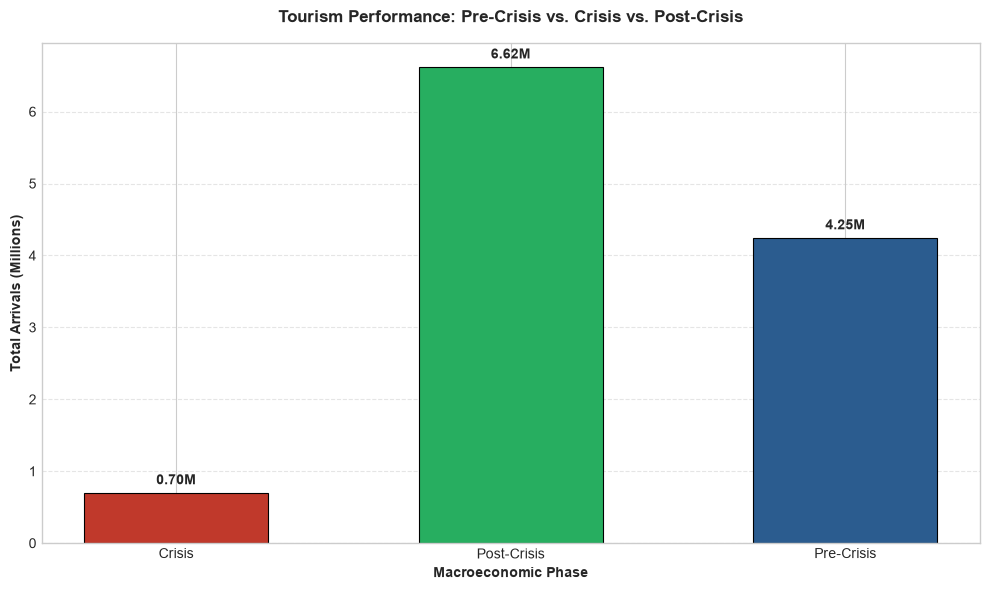

In [28]:
plt.figure(figsize=(10, 6))

period_colors = {
    "Pre-Crisis": "#2b5c8f",
    "Crisis": "#c0392b",
    "Post-Crisis": "#27ae60"
}

colors = [period_colors.get(p, "gray") for p in period_summary["Period"]]

bars = plt.bar(
    period_summary["Period"],
    period_summary["Tourist_Arrivals"] / 1e6,
    color=colors,
    edgecolor="black",
    linewidth=0.8,
    width=0.55
)

for bar in bars:
    h = bar.get_height()
    plt.annotate(
        f"{h:.2f}M",
        (bar.get_x() + bar.get_width() / 2, h),
        xytext=(0, 6),
        textcoords="offset points",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

plt.title("Tourism Performance: Pre-Crisis vs. Crisis vs. Post-Crisis", pad=15)
plt.xlabel("Macroeconomic Phase", fontweight="bold")
plt.ylabel("Total Arrivals (Millions)", fontweight="bold")
plt.grid(True, linestyle="--", alpha=0.5, axis="y")

plt.tight_layout()
plt.show()

### Tourism_Recovery_Analysis

In [29]:
yearly = (
    df.groupby("Year")["Tourist_Arrivals"]
    .sum()
    .reset_index()
)

baseline = yearly.loc[
    yearly["Year"] == 2019,
    "Tourist_Arrivals"
].iloc[0]

yearly["Recovery_Index"] = (
    yearly["Tourist_Arrivals"]
    / baseline
    * 100
)

yearly

,Year,Tourist_Arrivals,Recovery_Index
0,2018,2333796.0,121.951903
1,2019,1913702.0,100.000000
2,2020,507702.0,26.529836
3,2021,194494.0,10.163233
4,2022,719978.0,37.622263
5,2023,1487303.0,77.718631
6,2024,2053465.0,107.303279
7,2025,2362521.0,123.452920


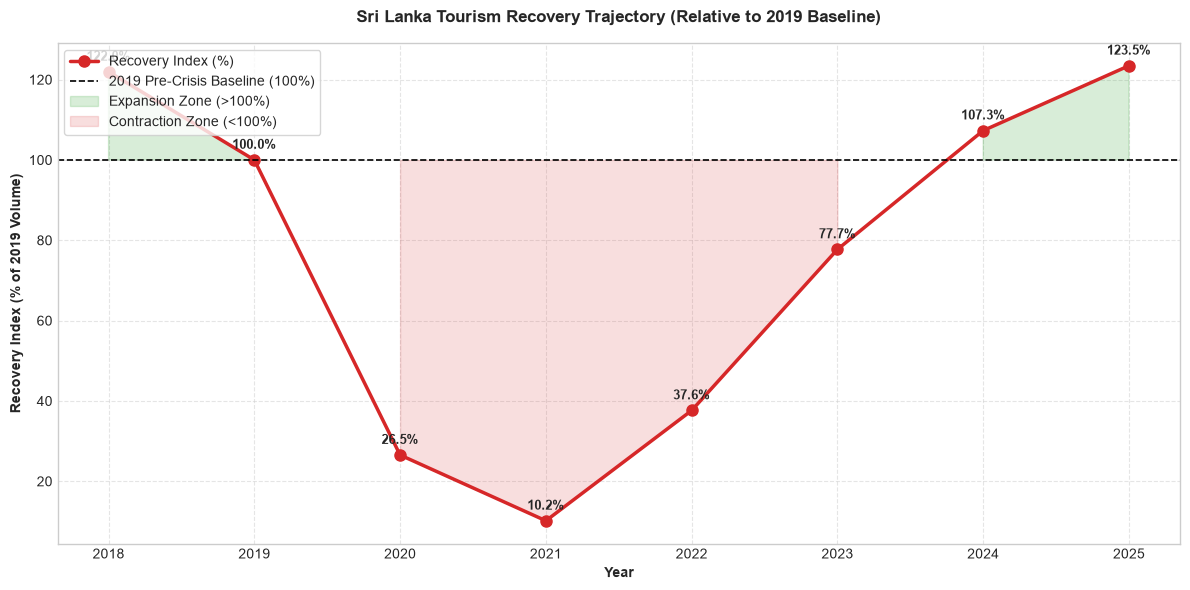

In [30]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    yearly["Year"],
    yearly["Recovery_Index"],
    marker="o",
    color="#d62728",
    linewidth=2.5,
    markersize=8,
    label="Recovery Index (%)"
)

ax.axhline(
    100,
    color="black",
    linestyle="--",
    linewidth=1.2,
    label="2019 Pre-Crisis Baseline (100%)"
)

ax.fill_between(
    yearly["Year"],
    100,
    yearly["Recovery_Index"],
    where=(yearly["Recovery_Index"] >= 100),
    color="#2ca02c",
    alpha=0.18,
    label="Expansion Zone (>100%)"
)

ax.fill_between(
    yearly["Year"],
    100,
    yearly["Recovery_Index"],
    where=(yearly["Recovery_Index"] < 100),
    color="#d62728",
    alpha=0.15,
    label="Contraction Zone (<100%)"
)

for _, row in yearly.iterrows():
    ax.annotate(
        f"{row['Recovery_Index']:.1f}%",
        (row["Year"], row["Recovery_Index"]),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
        fontsize=9.5,
        fontweight="bold"
    )

ax.set_title("Sri Lanka Tourism Recovery Trajectory (Relative to 2019 Baseline)", pad=15)
ax.set_xlabel("Year", fontweight="bold")
ax.set_ylabel("Recovery Index (% of 2019 Volume)", fontweight="bold")
ax.legend(loc="upper left", frameon=True)
ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

### Long Term CAGR Analysis

In [31]:
yearly = (
    df.groupby("Year")["Tourist_Arrivals"]
    .sum()
    .reset_index()
)

start_year = yearly["Year"].min()
end_year = yearly["Year"].max()

start_value = yearly.loc[
    yearly["Year"] == start_year,
    "Tourist_Arrivals"
].iloc[0]

end_value = yearly.loc[
    yearly["Year"] == end_year,
    "Tourist_Arrivals"
].iloc[0]

years = end_year - start_year

CAGR = (
    (end_value / start_value)
    ** (1 / years)
    - 1
) * 100

print(
    f"CAGR from {start_year} to {end_year}: "
    f"{CAGR:.2f}%"
)

CAGR from 2018 to 2025: 0.17%


### Tourism_Market_Segmentation

In [32]:
country = (
    df.groupby("Country")["Tourist_Arrivals"]
    .sum()
    .reset_index()
)

q1 = country["Tourist_Arrivals"].quantile(0.25)
q2 = country["Tourist_Arrivals"].quantile(0.50)
q3 = country["Tourist_Arrivals"].quantile(0.75)

In [33]:
def classify_market(value):
    
    if value >= q3:
        return "High Volume"
    
    elif value >= q2:
        return "Medium-High Volume"
    
    elif value >= q1:
        return "Medium-Low Volume"
    
    else:
        return "Low Volume"


country["Market_Segment"] = (
    country["Tourist_Arrivals"]
    .apply(classify_market)
)

country.head()

,Country,Tourist_Arrivals,Market_Segment
0,Afghanistan,1992.0,Medium-High Volume
1,Albania,1109.0,Medium-High Volume
2,Algeria,2214.0,Medium-High Volume
3,Andorra,449.0,Medium-Low Volume
4,Angola,95.0,Low Volume


In [34]:
segment_summary = (
    country.groupby("Market_Segment")
    ["Tourist_Arrivals"]
    .agg(
        Countries="count",
        Total_Arrivals="sum"
    )
    .reset_index()
)

segment_summary

,Market_Segment,Countries,Total_Arrivals
0,High Volume,51,11175823.0
1,Low Volume,51,2546.0
2,Medium-High Volume,51,373392.0
3,Medium-Low Volume,50,21200.0


### Top_and_Emerging_Markets

In [35]:
country_year = (
    df.groupby(
        ["Country", "Year"]
    )["Tourist_Arrivals"]
    .sum()
    .reset_index()
)

latest_year = country_year["Year"].max()

latest = country_year[
    country_year["Year"] == latest_year
].copy()

top_markets = latest.sort_values(
    "Tourist_Arrivals",
    ascending=False
).head(20)

top_markets

,Country,Year,Tourist_Arrivals
608,India,2025,531511.0
1449,United Kingdom,2025,212277.0
1127,Russia,2025,186580.0
509,Germany,2025,147966.0
286,China,2025,132035.0
74,Australia,2025,109487.0
477,France,2025,109041.0
1457,United States,2025,65973.0
968,Netherlands,2025,64164.0
114,Bangladesh,2025,59563.0


In [36]:
growth = country_year.pivot(
    index="Country",
    columns="Year",
    values="Tourist_Arrivals"
)

first_year = growth.columns.min()
last_year = growth.columns.max()

growth["Growth_%"] = (
    (growth[last_year] - growth[first_year])
    / growth[first_year].replace(0, np.nan)
    * 100
)

emerging = growth.sort_values(
    "Growth_%",
    ascending=False
)

emerging.head(20)

Year,2018,2019,2020,2021,2022,2023,2024,2025,Growth_%
Country,,,,,,,,,
Seychelles,416.0,1.0,106.0,118.0,347.0,1358.0,2691.0,3468.0,733.653846
Bangladesh,10487.0,8261.0,1986.0,1496.0,3817.0,17846.0,39555.0,59563.0,467.969867
Central African Republic,1.0,NaN,NaN,1.0,NaN,2.0,32.0,5.0,400.000000
St. Lucia,7.0,9.0,1.0,3.0,7.0,12.0,29.0,32.0,357.142857
Mauritania,3.0,29.0,1.0,0.0,5.0,7.0,9.0,13.0,333.333333
St. Kitts and Nevis,47.0,44.0,15.0,22.0,46.0,94.0,152.0,183.0,289.361702
Vanuatu,17.0,6.0,6.0,6.0,10.0,41.0,61.0,65.0,282.352941
Kazakhstan,2721.0,2399.0,2333.0,5754.0,8068.0,5130.0,11383.0,9281.0,241.087835
Dominica,49.0,62.0,10.0,8.0,37.0,85.0,124.0,166.0,238.775510


### Market_Volatility_Analysis

In [37]:
country_year = (
    df.groupby(
        ["Country", "Year"]
    )["Tourist_Arrivals"]
    .sum()
    .reset_index()
)

volatility = (
    country_year
    .groupby("Country")["Tourist_Arrivals"]
    .agg(
        Mean="mean",
        Std="std"
    )
    .reset_index()
)

volatility["CV_%"] = (
    volatility["Std"]
    / volatility["Mean"]
    * 100
)

volatility = volatility.sort_values(
    "CV_%",
    ascending=False
)

volatility.head(20)

,Country,Mean,Std,CV_%
34,Central African Republic,8.200000,13.405223,163.478328
125,Nauru,1.857143,2.794553,150.475905
133,North Korea,13.000000,19.052559,146.558145
9,Aruba,1.000000,1.414214,141.421356
197,Vatican,0.500000,0.707107,141.421356
138,Palau,11.000000,15.427249,140.247715
176,Syria,59.750000,77.887740,130.356050
157,Seychelles,1063.125000,1330.382162,125.138828
15,Bangladesh,17876.375000,20953.293079,117.212204
0,Afghanistan,249.000000,285.434506,114.632332


### Tourism_Demand_Index

In [38]:
monthly = (
    df.groupby("Date")["Tourist_Arrivals"]
    .sum()
    .reset_index()
)

average_demand = monthly[
    "Tourist_Arrivals"
].mean()

monthly["Demand_Index"] = (
    monthly["Tourist_Arrivals"]
    / average_demand
    * 100
)

monthly.head()

,Date,Tourist_Arrivals,Demand_Index
0,2018-01-01,238924.0,198.192183
1,2018-02-01,235618.0,195.449790
2,2018-03-01,233382.0,193.594984
3,2018-04-01,180429.0,149.669423
4,2018-05-01,129466.0,107.394607


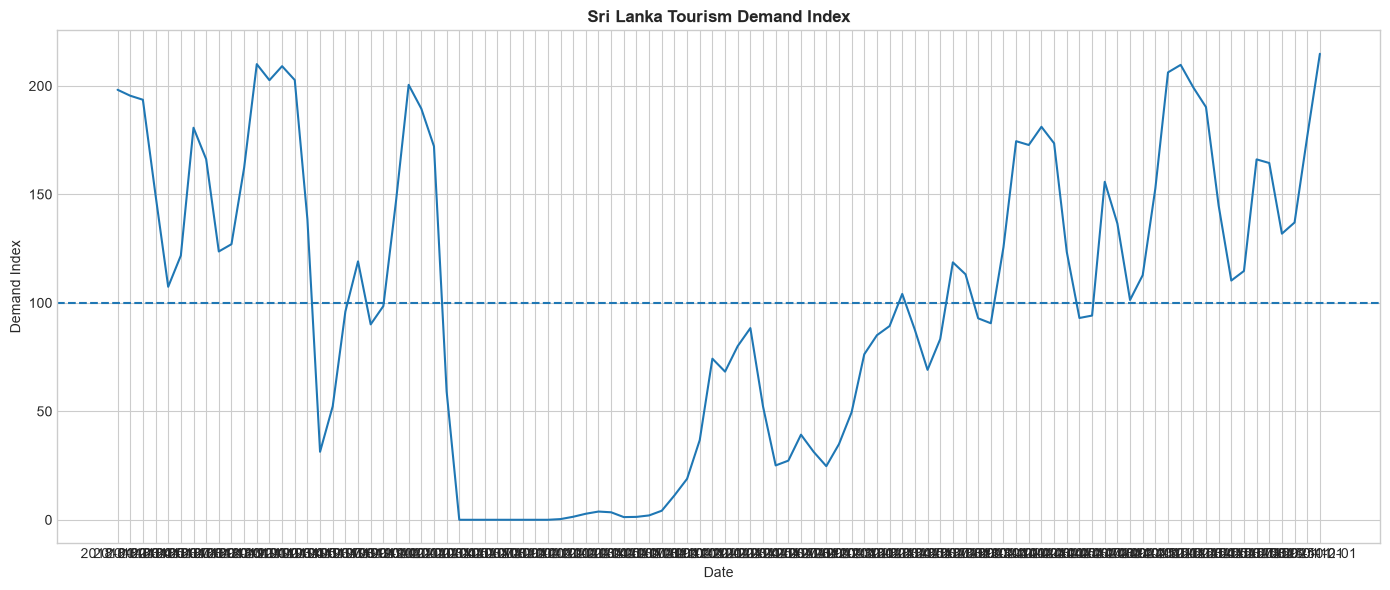

In [39]:
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=monthly,
    x="Date",
    y="Demand_Index"
)

plt.axhline(
    100,
    linestyle="--"
)

plt.title(
    "Sri Lanka Tourism Demand Index"
)

plt.ylabel("Demand Index")

plt.tight_layout()
plt.show()

### Time_Series_Analysis

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

monthly = (
    df.groupby("Date")["Tourist_Arrivals"]
    .sum()
    .sort_index()
)

monthly.index = pd.DatetimeIndex(
    monthly.index
)

monthly.head()

Date
2018-01-01    238924.0
2018-02-01    235618.0
2018-03-01    233382.0
2018-04-01    180429.0
2018-05-01    129466.0
Name: Tourist_Arrivals, dtype: float64

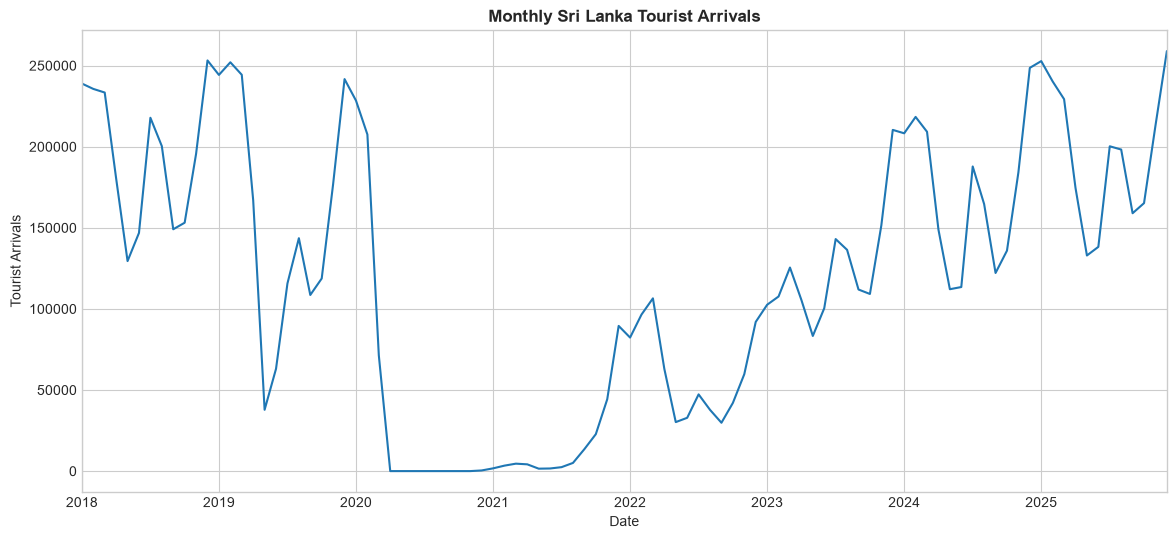

In [41]:
plt.figure(figsize=(14, 6))

monthly.plot()

plt.title(
    "Monthly Sri Lanka Tourist Arrivals"
)

plt.ylabel("Tourist Arrivals")
plt.grid(True)

plt.show()

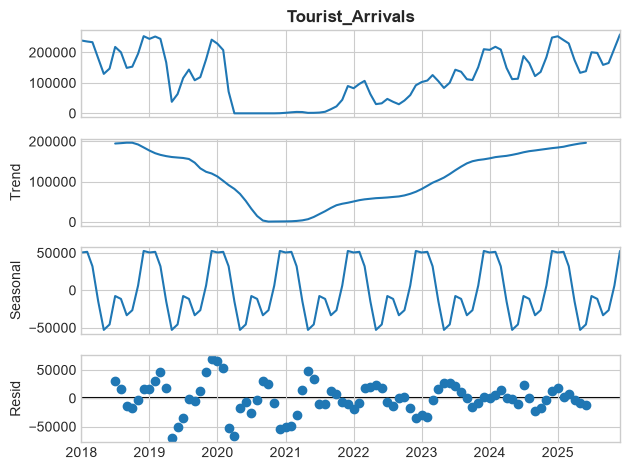

In [42]:
decomposition = seasonal_decompose(
    monthly,
    model="additive",
    period=12
)

decomposition.plot()

plt.tight_layout()
plt.show()

### Tourism_Forecasting

In [43]:
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

In [44]:
monthly = (
    df.groupby("Date")["Tourist_Arrivals"]
    .sum()
    .sort_index()
)

monthly.index = pd.DatetimeIndex(
    monthly.index
)

monthly = monthly.asfreq("MS")

In [45]:
train = monthly.iloc[:-12]
test = monthly.iloc[-12:]

print("Training:", len(train))
print("Testing:", len(test))

Training: 84
Testing: 12


In [46]:
model = SARIMAX(
    train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

model_fit = model.fit(
    disp=False
)

print(model_fit.summary())

                                     SARIMAX Results                                      
Dep. Variable:                   Tourist_Arrivals   No. Observations:                   84
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -660.168
Date:                            Tue, 29 Sep 2026   AIC                           1330.336
Time:                                    00:36:21   BIC                           1340.551
Sample:                                01-01-2018   HQIC                          1334.306
                                     - 12-01-2024                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3405      0.397     -0.858      0.391      -1.118       0.437
ma.L1          0.6836      0.244   

In [47]:
forecast = model_fit.forecast(
    steps=len(test)
)

forecast.index = test.index

In [48]:
mae = mean_absolute_error(
    test,
    forecast
)

rmse = np.sqrt(
    mean_squared_error(
        test,
        forecast
    )
)

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 37318.539265012005
RMSE: 39751.2154435823


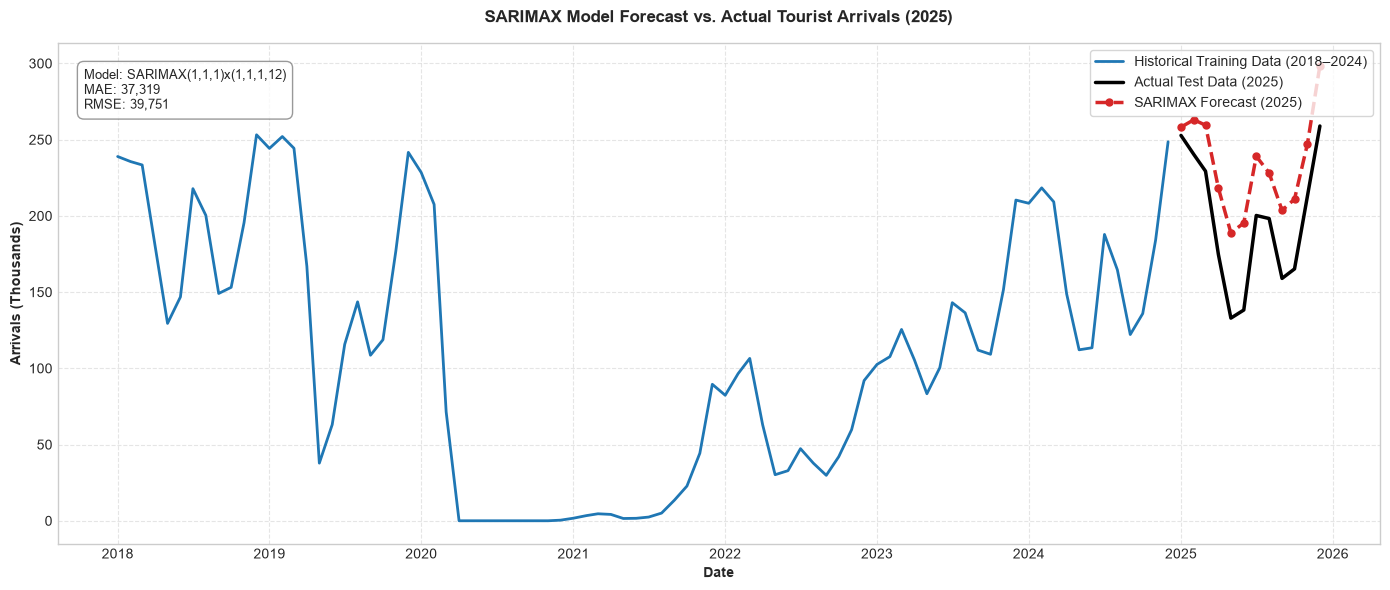

In [49]:
plt.figure(figsize=(14, 6))

plt.plot(
    train.index,
    train / 1e3,
    color="#1f77b4",
    linewidth=2,
    label="Historical Training Data (2018–2024)"
)

plt.plot(
    test.index,
    test / 1e3,
    color="black",
    linewidth=2.5,
    label="Actual Test Data (2025)"
)

plt.plot(
    forecast.index,
    forecast / 1e3,
    color="#d62728",
    linestyle="--",
    linewidth=2.5,
    marker="o",
    markersize=5,
    label="SARIMAX Forecast (2025)"
)

# Text box with evaluation metrics
metrics_text = f"Model: SARIMAX(1,1,1)x(1,1,1,12)\nMAE: {mae:,.0f}\nRMSE: {rmse:,.0f}"
plt.gca().text(
    0.02, 0.95,
    metrics_text,
    transform=plt.gca().transAxes,
    fontsize=9.5,
    verticalalignment="top",
    bbox=dict(boxstyle="round,pad=0.5", facecolor="white", alpha=0.8, edgecolor="gray")
)

plt.title("SARIMAX Model Forecast vs. Actual Tourist Arrivals (2025)", pad=15)
plt.xlabel("Date", fontweight="bold")
plt.ylabel("Arrivals (Thousands)", fontweight="bold")
plt.legend(loc="upper right", frameon=True)
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

### What_If_Scenario_Analysis

In [50]:
yearly = (
    df.groupby("Year")["Tourist_Arrivals"]
    .sum()
    .reset_index()
)

latest_value = yearly[
    yearly["Year"] == yearly["Year"].max()
]["Tourist_Arrivals"].iloc[0]

print(
    "Latest tourism arrivals:",
    latest_value
)

Latest tourism arrivals: 2362521.0


In [51]:
yearly = (
    df.groupby("Year")["Tourist_Arrivals"]
    .sum()
    .reset_index()
)

latest_value = yearly[
    yearly["Year"] == yearly["Year"].max()
]["Tourist_Arrivals"].iloc[0]

print(
    "Latest tourism arrivals:",
    latest_value
)

Latest tourism arrivals: 2362521.0


In [52]:
scenarios = pd.DataFrame({
    "Scenario": [
        "Downside",
        "Baseline",
        "Growth +10%",
        "Growth +20%"
    ],
    
    "Change_%": [
        -10,
        0,
        10,
        20
    ]
})

scenarios["Projected_Arrivals"] = (
    latest_value
    * (1 + scenarios["Change_%"] / 100)
)

scenarios

,Scenario,Change_%,Projected_Arrivals
0,Downside,-10,2126268.9
1,Baseline,0,2362521.0
2,Growth +10%,10,2598773.1
3,Growth +20%,20,2835025.2


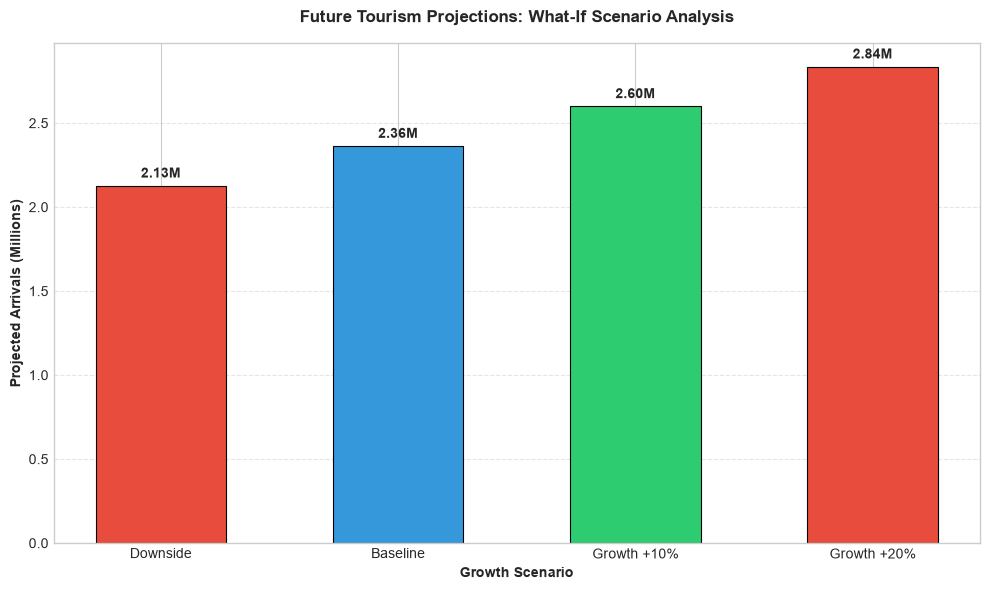

In [53]:
plt.figure(figsize=(10, 6))

scenario_colors = ["#e74c3c", "#3498db", "#2ecc71"]

bars = plt.bar(
    scenarios["Scenario"],
    scenarios["Projected_Arrivals"] / 1e6,
    color=scenario_colors,
    edgecolor="black",
    linewidth=0.8,
    width=0.55
)

for bar in bars:
    h = bar.get_height()
    plt.annotate(
        f"{h:.2f}M",
        (bar.get_x() + bar.get_width() / 2, h),
        xytext=(0, 6),
        textcoords="offset points",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

plt.title("Future Tourism Projections: What-If Scenario Analysis", pad=15)
plt.xlabel("Growth Scenario", fontweight="bold")
plt.ylabel("Projected Arrivals (Millions)", fontweight="bold")
plt.grid(True, linestyle="--", alpha=0.5, axis="y")

plt.tight_layout()
plt.show()

### Final_Business_Insights

In [54]:
import pandas as pd
import numpy as np

df = pd.read_csv(
    "../data/processed/tourism_arrivals_clean.csv"
)

In [55]:
total_arrivals = df[
    "Tourist_Arrivals"
].sum()

years = df["Year"].nunique()

countries = df["Country"].nunique()

average_monthly = (
    df.groupby("Date")["Tourist_Arrivals"]
    .sum()
    .mean()
)

print("Total Tourist Arrivals:", total_arrivals)
print("Years Covered:", years)
print("Countries Covered:", countries)
print("Average Monthly Arrivals:", average_monthly)

Total Tourist Arrivals: 11572961.0
Years Covered: 8
Countries Covered: 203
Average Monthly Arrivals: 120551.67708333333


In [56]:
yearly = (
    df.groupby("Year")["Tourist_Arrivals"]
    .sum()
    .reset_index()
)

highest_year = yearly.loc[
    yearly["Tourist_Arrivals"].idxmax()
]

print(
    "Highest Tourism Year:",
    highest_year["Year"]
)

print(
    "Arrivals:",
    highest_year["Tourist_Arrivals"]
)

Highest Tourism Year: 2025.0
Arrivals: 2362521.0


In [57]:
lowest_year = yearly.loc[
    yearly["Tourist_Arrivals"].idxmin()
]

print(
    "Lowest Tourism Year:",
    lowest_year["Year"]
)

print(
    "Arrivals:",
    lowest_year["Tourist_Arrivals"]
)

Lowest Tourism Year: 2021.0
Arrivals: 194494.0


In [58]:
top_country = (
    df.groupby("Country")
    ["Tourist_Arrivals"]
    .sum()
    .sort_values(
        ascending=False
    )
    .head(10)
)

print(top_country)

Country
India             2299847.0
United Kingdom    1130944.0
Russia             894607.0
China              799612.0
Germany            780867.0
Australia          525726.0
France             515008.0
United States      361185.0
Maldives           292660.0
Canada             278059.0
Name: Tourist_Arrivals, dtype: float64


In [59]:
best_month = (
    df.groupby(
        ["Month_Number", "Month"]
    )["Tourist_Arrivals"]
    .sum()
    .sort_values(
        ascending=False
    )
    .head(1)
)

best_month

Month_Number  Month   
12            December    1394564.0
Name: Tourist_Arrivals, dtype: float64

In [60]:
yearly["Recovery_Index"] = (
    yearly["Tourist_Arrivals"]
    / yearly.loc[
        yearly["Year"] == 2019,
        "Tourist_Arrivals"
    ].iloc[0]
    * 100
)

yearly

,Year,Tourist_Arrivals,Recovery_Index
0,2018,2333796.0,121.951903
1,2019,1913702.0,100.000000
2,2020,507702.0,26.529836
3,2021,194494.0,10.163233
4,2022,719978.0,37.622263
5,2023,1487303.0,77.718631
6,2024,2053465.0,107.303279
7,2025,2362521.0,123.452920


In [61]:
top10 = (
    df.groupby("Country")
    ["Tourist_Arrivals"]
    .sum()
    .sort_values(
        ascending=False
    )
    .head(10)
)

top10

Country
India             2299847.0
United Kingdom    1130944.0
Russia             894607.0
China              799612.0
Germany            780867.0
Australia          525726.0
France             515008.0
United States      361185.0
Maldives           292660.0
Canada             278059.0
Name: Tourist_Arrivals, dtype: float64

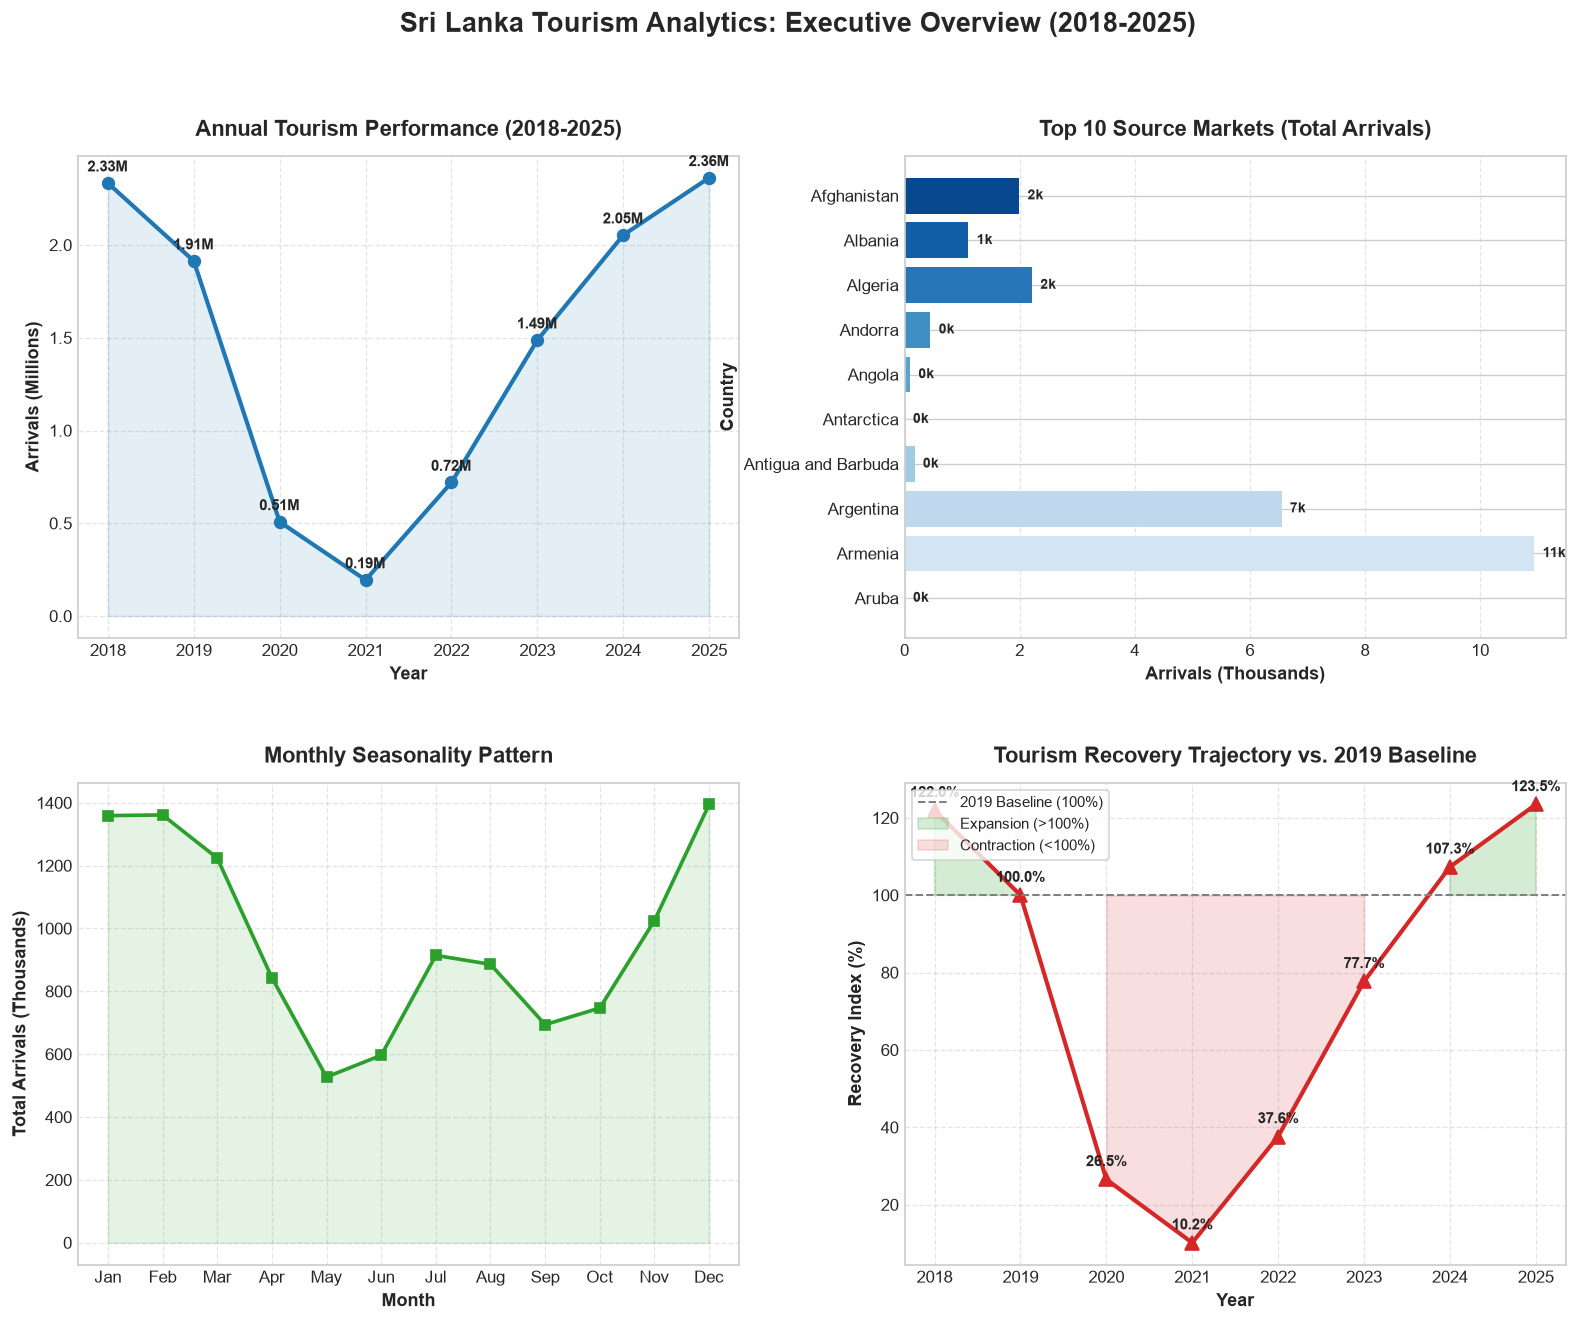

In [62]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12), dpi=120)
plt.subplots_adjust(hspace=0.3, wspace=0.25)

# Panel 1: Yearly Performance
axes[0, 0].plot(yearly["Year"], yearly["Tourist_Arrivals"] / 1e6, marker="o", color="#1f77b4", linewidth=2.5, markersize=7)
axes[0, 0].fill_between(yearly["Year"], yearly["Tourist_Arrivals"] / 1e6, color="#1f77b4", alpha=0.12)
axes[0, 0].set_title("Annual Tourism Performance (2018-2025)", fontsize=13, fontweight="bold", pad=12)
axes[0, 0].set_ylabel("Arrivals (Millions)", fontsize=11, fontweight="bold")
axes[0, 0].set_xlabel("Year", fontsize=11, fontweight="bold")
axes[0, 0].grid(True, linestyle="--", alpha=0.5)
for _, r in yearly.iterrows():
    axes[0, 0].annotate(f"{r['Tourist_Arrivals']/1e6:.2f}M", (r["Year"], r["Tourist_Arrivals"] / 1e6),
                        xytext=(0, 7), textcoords="offset points", ha="center", fontsize=9, fontweight="bold")

# Panel 2: Top 10 Source Markets
top10_clean = country.head(10).copy()
colors = sns.color_palette("Blues_r", 10)
bars = axes[0, 1].barh(top10_clean["Country"][::-1], top10_clean["Tourist_Arrivals"][::-1] / 1e3, color=colors[::-1], edgecolor="none")
axes[0, 1].set_title("Top 10 Source Markets (Total Arrivals)", fontsize=13, fontweight="bold", pad=12)
axes[0, 1].set_xlabel("Arrivals (Thousands)", fontsize=11, fontweight="bold")
axes[0, 1].set_ylabel("Country", fontsize=11, fontweight="bold")
axes[0, 1].grid(True, linestyle="--", alpha=0.5, axis="x")
for bar in bars:
    w = bar.get_width()
    axes[0, 1].annotate(f"{w:,.0f}k", (w, bar.get_y() + bar.get_height() / 2),
                        xytext=(5, 0), textcoords="offset points", va="center", fontsize=8.5, fontweight="bold")

# Panel 3: Monthly Seasonality
monthly_season = (
    df.groupby(["Month_Number", "Month"])["Tourist_Arrivals"]
    .sum()
    .reset_index()
    .sort_values("Month_Number")
)
month_abbr = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
axes[1, 0].plot(range(1, 13), monthly_season["Tourist_Arrivals"] / 1e3, marker="s", color="#2ca02c", linewidth=2.2, markersize=6)
axes[1, 0].fill_between(range(1, 13), monthly_season["Tourist_Arrivals"] / 1e3, color="#2ca02c", alpha=0.12)
axes[1, 0].set_xticks(range(1, 13))
axes[1, 0].set_xticklabels(month_abbr, rotation=0, fontsize=10)
axes[1, 0].set_title("Monthly Seasonality Pattern", fontsize=13, fontweight="bold", pad=12)
axes[1, 0].set_ylabel("Total Arrivals (Thousands)", fontsize=11, fontweight="bold")
axes[1, 0].set_xlabel("Month", fontsize=11, fontweight="bold")
axes[1, 0].grid(True, linestyle="--", alpha=0.5)

# Panel 4: Recovery Index
axes[1, 1].plot(yearly["Year"], yearly["Recovery_Index"], marker="^", color="#d62728", linewidth=2.5, markersize=8)
axes[1, 1].axhline(100, color="gray", linestyle="--", linewidth=1.2, label="2019 Baseline (100%)")
axes[1, 1].fill_between(yearly["Year"], 100, yearly["Recovery_Index"], where=(yearly["Recovery_Index"] >= 100),
                        color="#2ca02c", alpha=0.2, label="Expansion (>100%)")
axes[1, 1].fill_between(yearly["Year"], 100, yearly["Recovery_Index"], where=(yearly["Recovery_Index"] < 100),
                        color="#d62728", alpha=0.15, label="Contraction (<100%)")
axes[1, 1].set_title("Tourism Recovery Trajectory vs. 2019 Baseline", fontsize=13, fontweight="bold", pad=12)
axes[1, 1].set_ylabel("Recovery Index (%)", fontsize=11, fontweight="bold")
axes[1, 1].set_xlabel("Year", fontsize=11, fontweight="bold")
axes[1, 1].legend(loc="upper left", frameon=True, fontsize=9)
axes[1, 1].grid(True, linestyle="--", alpha=0.5)
for _, r in yearly.iterrows():
    axes[1, 1].annotate(f"{r['Recovery_Index']:.1f}%", (r["Year"], r["Recovery_Index"]),
                        xytext=(0, 8), textcoords="offset points", ha="center", fontsize=9, fontweight="bold")

plt.suptitle("Sri Lanka Tourism Analytics: Executive Overview (2018-2025)", fontsize=16, fontweight="bold", y=0.98)
os.makedirs("../outputs/figures", exist_ok=True)
plt.savefig("../outputs/figures/final_tourism_analysis.png", dpi=300, bbox_inches="tight")
plt.show()

In [63]:
insights = []

# Highest year
best_year = yearly.loc[
    yearly["Tourist_Arrivals"].idxmax()
]

insights.append({
    "Insight": "Highest Tourism Year",
    "Value": best_year["Year"],
    "Metric": best_year["Tourist_Arrivals"]
})

# Lowest year
worst_year = yearly.loc[
    yearly["Tourist_Arrivals"].idxmin()
]

insights.append({
    "Insight": "Lowest Tourism Year",
    "Value": worst_year["Year"],
    "Metric": worst_year["Tourist_Arrivals"]
})

# Top country
best_country = (
    df.groupby("Country")["Tourist_Arrivals"]
    .sum()
    .idxmax()
)

best_country_value = (
    df.groupby("Country")["Tourist_Arrivals"]
    .sum()
    .max()
)

insights.append({
    "Insight": "Largest Source Market",
    "Value": best_country,
    "Metric": best_country_value
})

# Best month
best_month_row = (
    df.groupby(
        ["Month_Number", "Month"]
    )["Tourist_Arrivals"]
    .sum()
    .idxmax()
)

best_month_value = (
    df.groupby(
        ["Month_Number", "Month"]
    )["Tourist_Arrivals"]
    .sum()
    .max()
)

insights.append({
    "Insight": "Highest Tourism Month",
    "Value": best_month_row[1],
    "Metric": best_month_value
})

insights_df = pd.DataFrame(insights)

insights_df

,Insight,Value,Metric
0,Highest Tourism Year,2025.0,2362521.0
1,Lowest Tourism Year,2021.0,194494.0
2,Largest Source Market,India,2299847.0
3,Highest Tourism Month,December,1394564.0


In [64]:
import os

os.makedirs("../outputs/tables", exist_ok=True)

insights_df.to_csv(
    "../outputs/tables/final_business_insights.csv",
    index=False
)

print(
    "Final business insights saved."
)

Final business insights saved.
